# Validation of GREMLIN Pytorch Implentation

**Machine:** MacBook Pro M1 Pro (10c 16GB)

**Devices:** CPU/MPS

**Control:** Previous run from Tensorflow v1

| Versions | File| Description | MD5 sum | Time (s) | Mem (GB) |
| -------- | --- | ---------- | -- | -- | -- |
| CPU | cpu.pkl | CPU version | 10b7fee0253aaa67afc75c5a529d780c | ~780 | 3.6-4.7 |
| GPU(MPS) | mps.pkl | GPU version (MPS), w/o Memory Optimized| fbe7beeb3d8c7b687e345e970754cb0c | ~600 | 9.99 | 
| GPU(MPS/MemOpt) | mps_memopt.pkl | GPU version (MPS), w/ Memory Optimized | f68762c2c0099df84fc764bef1397b95 | ~480 | 9.19 | 
| GPU(CPU Only) | cpuonly.pkl | GPU version, CPU only, w/ Memory Optimized | 8d4186e868bc569e1f6e304d431cf6b5| ~830 | 2.9-3.8 | 

## Imports and Functions

In [6]:
import os
import pickle
import numpy as np
import pandas as pd

import itertools

import glob
from scipy.spatial.distance import pdist, squareform
from scipy import stats


###################################
# Alphabet and Basic Setup
###################################
alphabet = "ARNDCQEGHILKMFPSTWYV-"
states = len(alphabet)
a2n = {a: i for i, a in enumerate(alphabet)}


def aa2num(aa):
    if aa in a2n:
        return a2n[aa]
    else:
        return a2n['-']


# resuilts from gremlin pytorch, cpu, mps, mps_memopt, mps_mem_opt.r2
resdir='/Users/yyy/Documents/projects/taxol/t5ah2/Evo/T5aH2_wt_PSSM_GREMLIN_results/gremlin_msa'



all_pkls = glob.glob(resdir+'/*.pkl')

all_res={
    os.path.basename(x).removesuffix('.pkl'):x for x in all_pkls
}

# control group from orginal TF version
all_res['control']='/Users/yyy/Documents/projects/taxol/t5ah2/Evo/T5aH2_wt_PSSM_GREMLIN_results/gremlin_res/T5aH2_wt.i90c75_aln.GREMLIN.mrf.pkl'

msa_file=os.path.join(resdir, 'T5aH2_wt.i90c75_aln.fas')

# from GREMLIN
def get_mtx(mrf):
    raw = np.sqrt(np.sum(mrf["w"][:, :-1, :-1] ** 2, axis=(1, 2)))
    raw_sq = squareform(raw)
    ap_sq = np.sum(raw_sq, 0, keepdims=True) * np.sum(raw_sq, 1, keepdims=True) / np.sum(raw_sq)
    apc = squareform(raw_sq - ap_sq, checks=False)
    return {
        "i": mrf["w_idx"][:, 0],
        "j": mrf["w_idx"][:, 1],
        "raw": raw,
        "apc": apc,
        "zscore": normalize(apc),
    }


def plot_mtx(mtx, key="zscore", vmin=1, vmax=3):
    """
    Quick convenience plot, ensuring it's a separate figure.
    """
    import matplotlib.pylab as plt

    plt.figure()
    plt.imshow(squareform(mtx[key]), cmap="Blues", interpolation="none", vmin=vmin, vmax=vmax)
    plt.grid(False)
    plt.show()


###################################
# Extra contact map utilities
###################################
# from GREMLIN
def normalize(x):
    x = stats.boxcox(x - np.amin(x) + 1.0)[0]
    mean_x = np.mean(x)
    std_x = np.std(x)
    return (x - mean_x)/(std_x + 1e-8)

# from GREMLIN
def load_mrf(pth):
    with open(pth,'rb') as f:
        res=pickle.load(f)
    return res


###################################
# FASTA Parse
###################################
def parse_fasta(filename, limit=-1):
    headers = []
    seqs = []
    with open(filename, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith(">"):
                if limit > 0 and len(headers) == limit:
                    break
                headers.append(line[1:])
                seqs.append([])
            else:
                seqs[-1].append(line)
    seqs = [''.join(s) for s in seqs]
    return np.array(headers), np.array(seqs)

###################################
# MSA Prep
###################################
def filt_gaps(msa, gap_cut=0.5):
    """Remove columns with more than gap_cut fraction of gaps."""
    gap_mask = (msa == states - 1).astype(np.float32)
    frac_gap = np.sum(gap_mask, axis=0) / msa.shape[0]
    keep_cols = np.where(frac_gap < gap_cut)[0]
    return msa[:, keep_cols], keep_cols

def get_eff(msa, eff_cut=0.8):
    """Compute sequence weights based on pairwise identity >= eff_cut."""
    pid = 1.0 - squareform(pdist(msa, 'hamming'))
    w = (pid >= eff_cut).astype(np.float32)
    return 1.0 / np.sum(w, axis=-1)

def mk_msa(seqs):
    """Make MSA dict from raw sequence strings."""
    msa_ori = []
    for s in seqs:
        msa_ori.append([aa2num(a) for a in s])
    msa_ori = np.array(msa_ori, dtype=np.int32)

    # remove gappy columns
    msa, v_idx = filt_gaps(msa_ori, 0.5)

    # weights
    weights = get_eff(msa, 0.8)
    nrow, ncol = msa.shape
    w_idx = v_idx[np.stack(np.triu_indices(ncol, 1), axis=-1)]

    return {
        "msa_ori": msa_ori,
        "msa": msa,
        "weights": weights,
        "neff": np.sum(weights),
        "v_idx": v_idx,
        "w_idx": w_idx,
        "nrow": nrow,
        "ncol": ncol,
        "ncol_ori": msa_ori.shape[1],
    }


## Validate MTX

Plotting MTX cpu: /Users/yyy/Documents/projects/taxol/t5ah2/Evo/T5aH2_wt_PSSM_GREMLIN_results/gremlin_msa/cpu.pkl


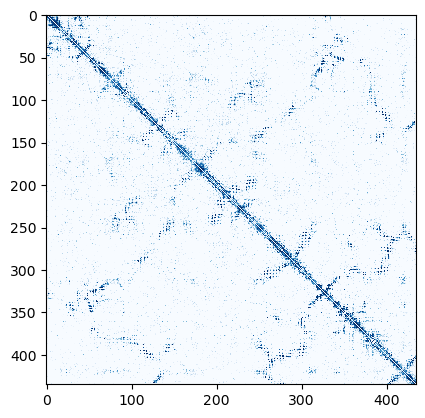

Plotting MTX mps_memopt: /Users/yyy/Documents/projects/taxol/t5ah2/Evo/T5aH2_wt_PSSM_GREMLIN_results/gremlin_msa/mps_memopt.pkl


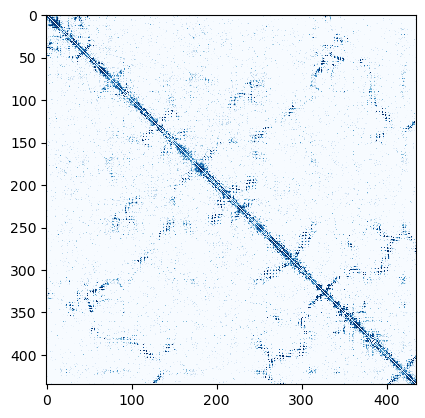

Plotting MTX mps: /Users/yyy/Documents/projects/taxol/t5ah2/Evo/T5aH2_wt_PSSM_GREMLIN_results/gremlin_msa/mps.pkl


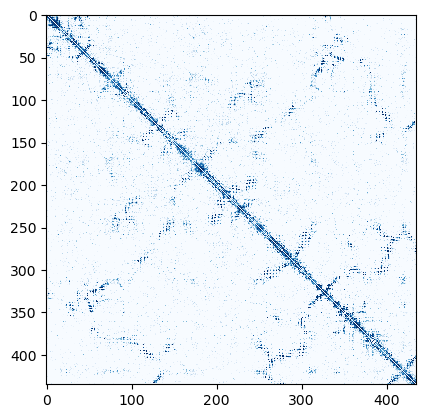

Plotting MTX cpuonly: /Users/yyy/Documents/projects/taxol/t5ah2/Evo/T5aH2_wt_PSSM_GREMLIN_results/gremlin_msa/cpuonly.pkl


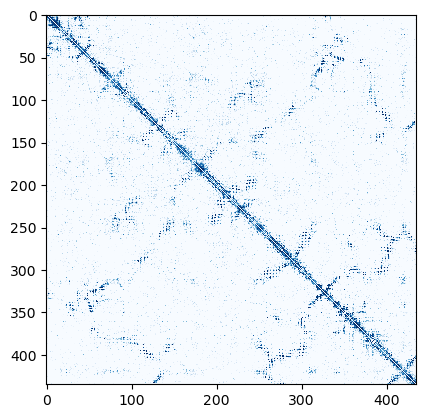

Plotting MTX control: /Users/yyy/Documents/projects/taxol/t5ah2/Evo/T5aH2_wt_PSSM_GREMLIN_results/gremlin_res/T5aH2_wt.i90c75_aln.GREMLIN.mrf.pkl


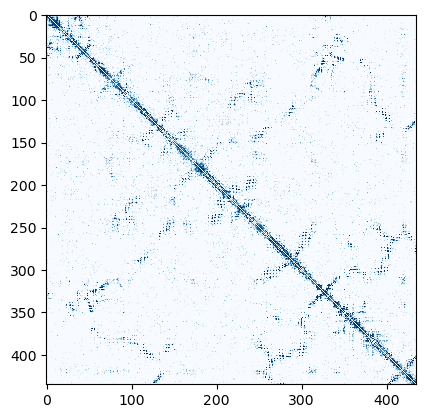

In [2]:
for k,v in all_res.items():
    print(f'Plotting MTX {k}: {v}')
    mrf=load_mrf(v)
    mtx = get_mtx(mrf)
    plot_mtx(mtx)
    

In [3]:
mtx

{'i': array([ 50,  50,  50, ..., 495, 495, 496], shape=(94395,)),
 'j': array([ 51,  52,  53, ..., 496, 497, 497], shape=(94395,)),
 'raw': array([0.5447625 , 0.4313149 , 0.28026414, ..., 0.6914801 , 0.4755005 ,
        0.55168796], shape=(94395,), dtype=float32),
 'apc': array([0.2538021 , 0.17290592, 0.03086054, ..., 0.36804962, 0.19652066,
        0.29863396], shape=(94395,), dtype=float32),
 'zscore': array([2.90763842, 2.6250364 , 1.03735712, ..., 3.07562511, 2.73079192,
        2.99397621], shape=(94395,))}

## Validate PSSM Term

In [4]:
import matplotlib.pylab as plt

# from GREMLIN
def plot_v(mrf):
  al_a = list(alphabet)
  v = mrf["v"].T
  mx = np.max((v.max(),np.abs(v.min())))
  plt.figure(figsize=(v.shape[1]/4,states/4))
  plt.imshow(-v,cmap='bwr',vmin=-mx,vmax=mx)
  plt.xticks(np.arange(v.shape[1]))
  plt.yticks(np.arange(0,states))
  plt.grid(False)
  ax = plt.gca()
  ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,y: mrf["v_idx"][x]))
  ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,y: al_a[x]))



Plotting MTX cpu: /Users/yyy/Documents/projects/taxol/t5ah2/Evo/T5aH2_wt_PSSM_GREMLIN_results/gremlin_msa/cpu.pkl
Plotting MTX mps_memopt: /Users/yyy/Documents/projects/taxol/t5ah2/Evo/T5aH2_wt_PSSM_GREMLIN_results/gremlin_msa/mps_memopt.pkl
Plotting MTX mps: /Users/yyy/Documents/projects/taxol/t5ah2/Evo/T5aH2_wt_PSSM_GREMLIN_results/gremlin_msa/mps.pkl
Plotting MTX cpuonly: /Users/yyy/Documents/projects/taxol/t5ah2/Evo/T5aH2_wt_PSSM_GREMLIN_results/gremlin_msa/cpuonly.pkl
Plotting MTX control: /Users/yyy/Documents/projects/taxol/t5ah2/Evo/T5aH2_wt_PSSM_GREMLIN_results/gremlin_res/T5aH2_wt.i90c75_aln.GREMLIN.mrf.pkl


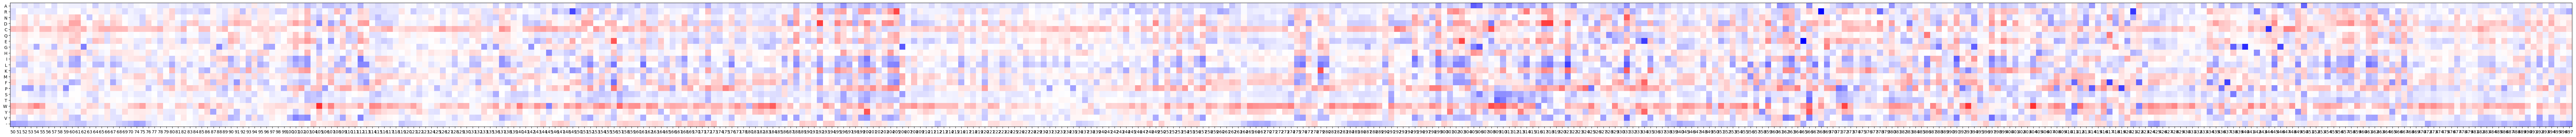

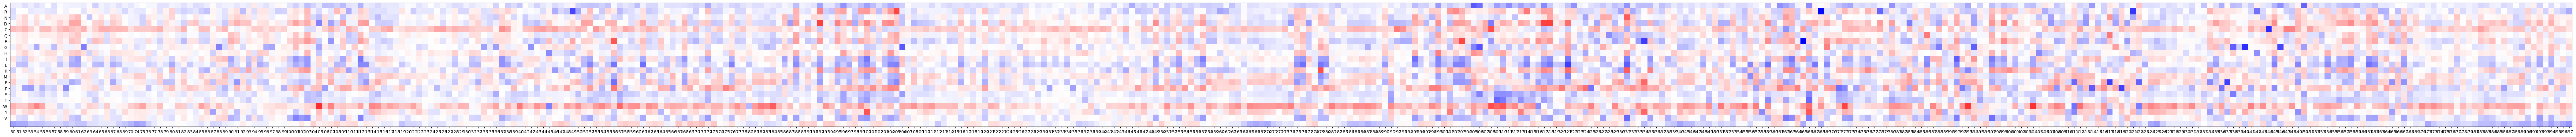

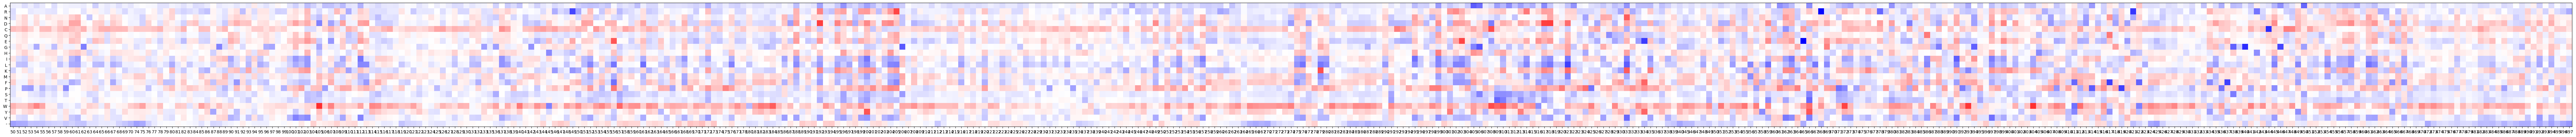

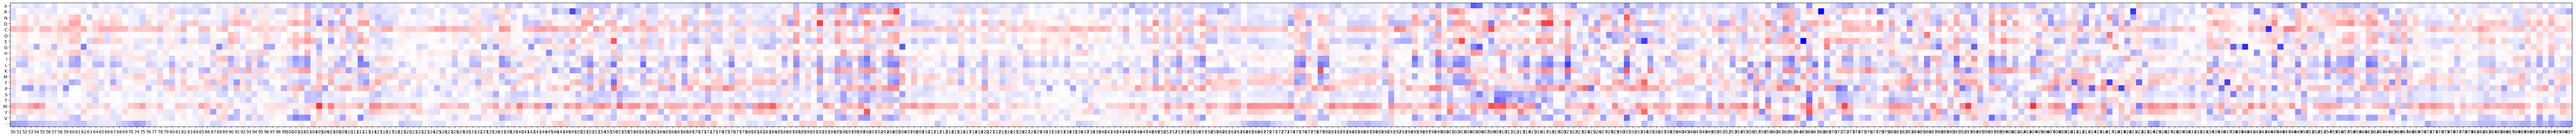

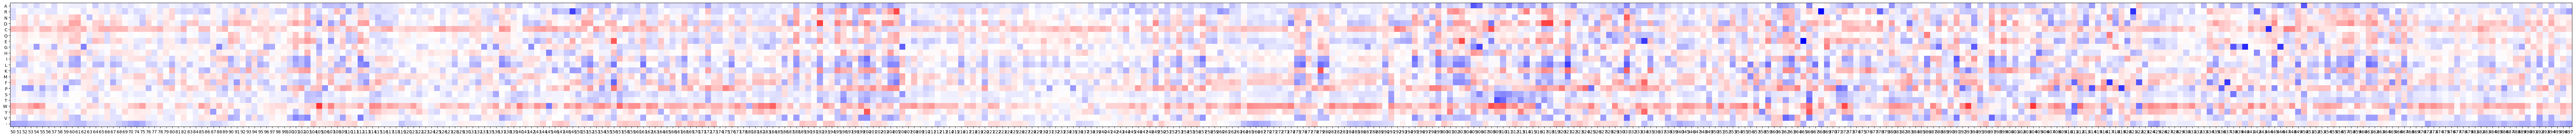

In [5]:
for k,v in all_res.items():
    print(f'Plotting MTX {k}: {v}')
    mrf=load_mrf(v)
    plot_v(mrf)
    

## Validate APC *vesus* Control

In [6]:
def compare_apc(path1, path2):
    mrf1=load_mrf(path1)
    mtx1 = get_mtx(mrf1)

    mrf2=load_mrf(path2)
    mtx2 = get_mtx(mrf2)
    
    plt.scatter(mtx1["apc"],mtx2["apc"])
    plt.show()

Test control vs cpu


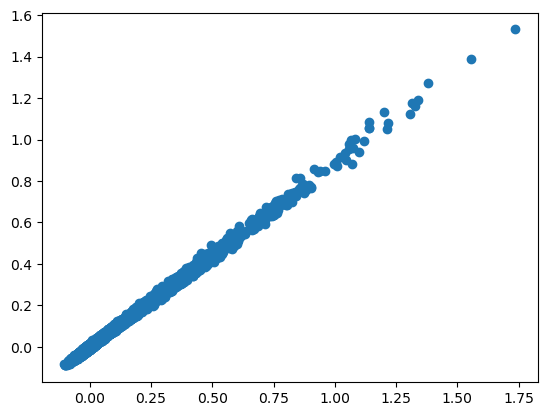

Test control vs mps_memopt


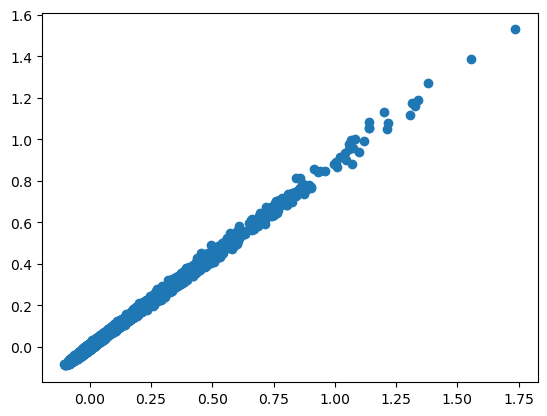

Test control vs mps


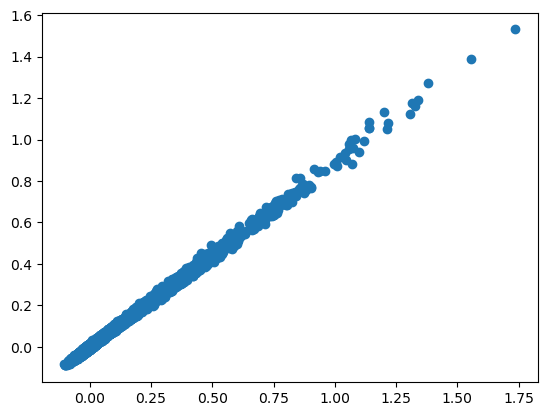

Test control vs cpuonly


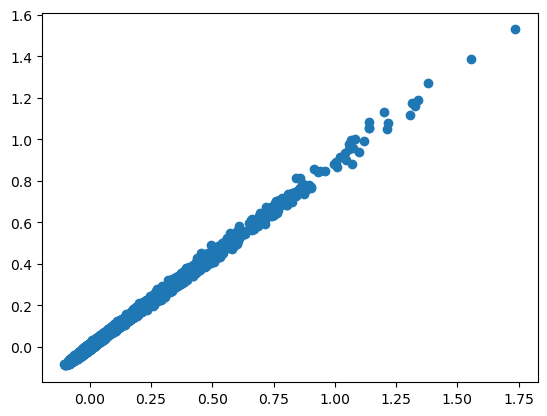

In [7]:
control,control_path='control',all_res.pop('control')
for k in all_res.keys():
    print(f'Test {control} vs {k}')
    compare_apc(control_path, all_res[k])

## Cross Validation 

Test control vs cpu


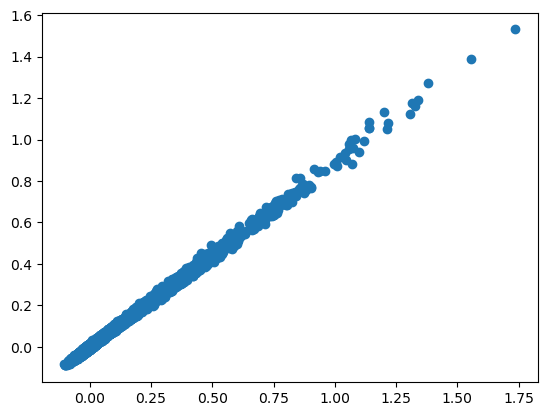

Test control vs mps_memopt


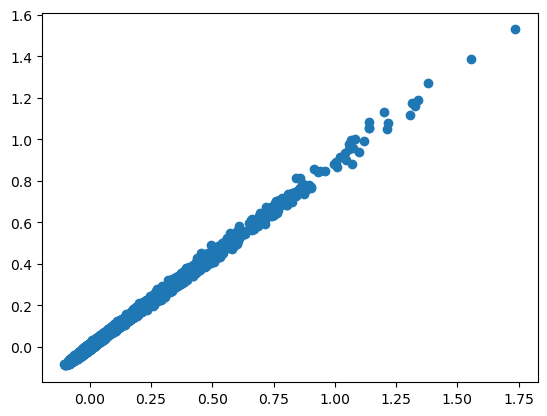

Test control vs mps


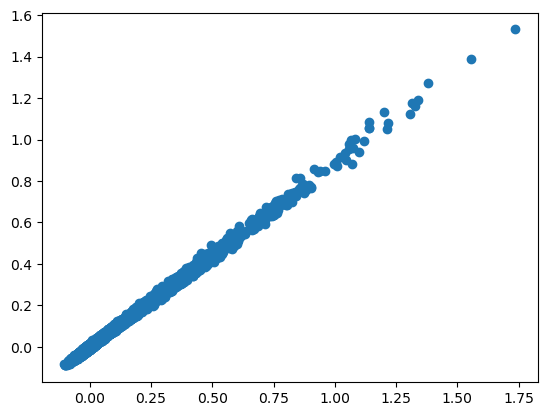

Test control vs cpuonly


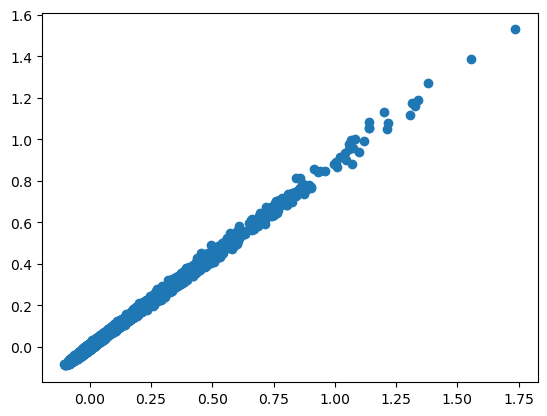

Test cpu vs mps_memopt


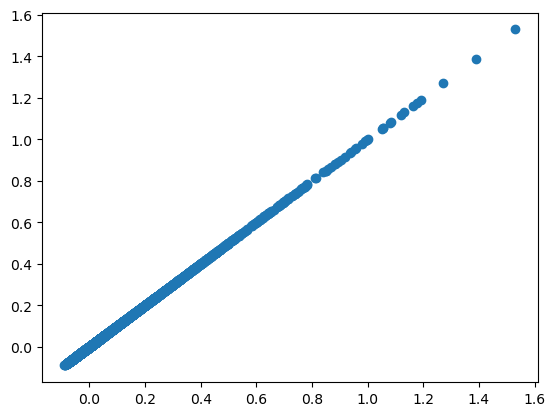

Test cpu vs mps


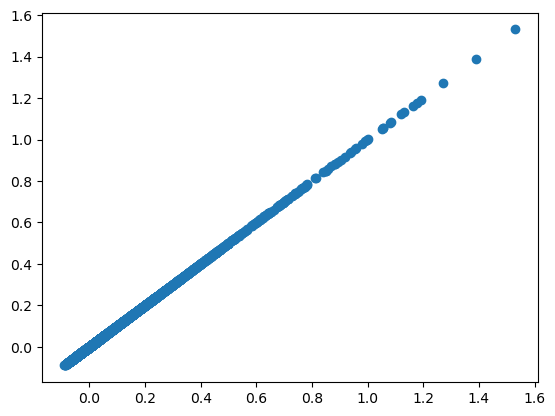

Test cpu vs cpuonly


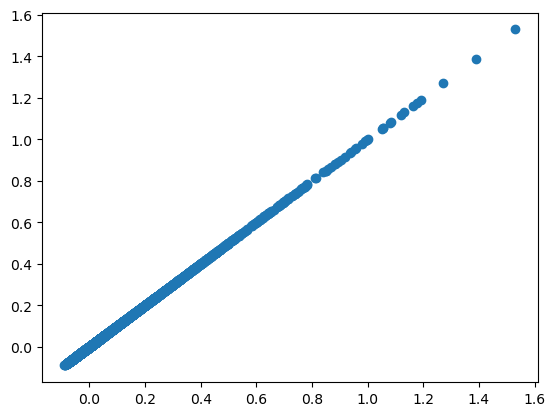

Test mps_memopt vs mps


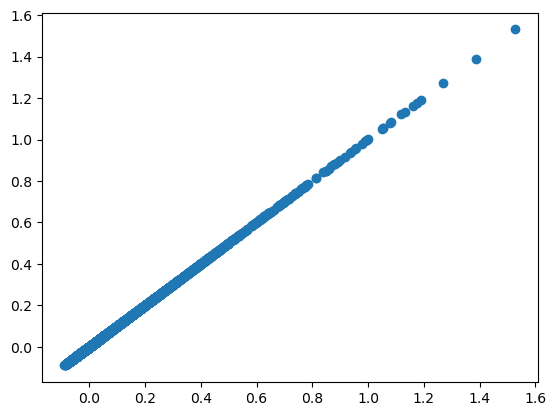

Test mps_memopt vs cpuonly


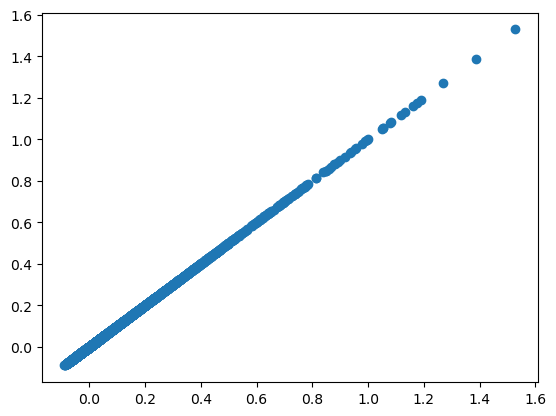

Test mps vs cpuonly


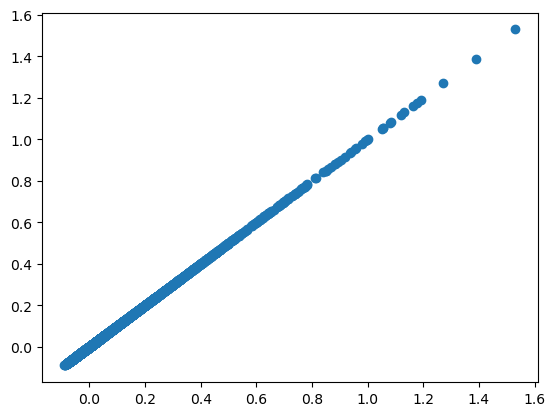

In [8]:
# control group from orginal TF version

all_res={'control': control_path, **all_res}
for i, j in itertools.combinations(all_res.keys(),2):
    print(f'Test {i} vs {j}')
    compare_apc(all_res[i], all_res[j])


## Validate Top Pairs

In [7]:
headers, seqs = parse_fasta(msa_file)
msa = mk_msa(seqs)

In [10]:
def list_pairs(mtx):
    ######################################################################################
    # WARNING - WARNING - WARNING
    ######################################################################################
    # - the i,j index starts at 0 (zero)
    # - the "first" position = 0
    # - often in biology first position of a sequence is 1
    #   for this index use i_aa and j_aa!
    
    # adding amino acid to index
    mtx["i_aa"] = np.array([alphabet[msa['msa_ori'][0][i]]+"_"+str(i+1) for i in mtx["i"]])
    mtx["j_aa"] = np.array([alphabet[msa['msa_ori'][0][j]]+"_"+str(j+1) for j in mtx["j"]])
    
    # load mtx into pandas dataframe
    pd_mtx = pd.DataFrame(mtx,columns=["i","j","apc","zscore","i_aa","j_aa"])
    
    # get contacts with sequence seperation > 5
    # sort by zscore, show top 10
    top = pd_mtx.loc[pd_mtx['j'] - pd_mtx['i'] > 5].sort_values("zscore",ascending=False)
    print(top.head(10))

In [11]:
for k,v in all_res.items():
    print(f'List pairs {k}: {v}')
    mrf=load_mrf(v)
    mtx = get_mtx(mrf)
    list_pairs(mtx)

List pairs cpu: /Users/yyy/Documents/projects/taxol/t5ah2/Evo/T5aH2_wt_PSSM_GREMLIN_results/gremlin_msa/cpu.pkl
         i    j       apc    zscore   i_aa   j_aa
85411  361  423  1.390058  3.159753  Q_362  D_424
68317  261  292  1.175853  3.159571  K_262  N_293
83225  346  352  1.132305  3.159496  E_347  D_353
94041  468  495  1.120652  3.159472  Y_469  F_496
93986  466  495  1.080919  3.159378  S_467  F_496
79214  317  366  1.055290  3.159303  I_318  T_367
81833  332  497  1.053779  3.159298  V_333  R_498
80891  327  358  1.051139  3.159289  C_328  Y_359
79306  317  458  0.991194  3.159051  I_318  V_459
85408  361  420  0.978516  3.158988  Q_362  S_421
List pairs mps_memopt: /Users/yyy/Documents/projects/taxol/t5ah2/Evo/T5aH2_wt_PSSM_GREMLIN_results/gremlin_msa/mps_memopt.pkl
         i    j       apc    zscore   i_aa   j_aa
85411  361  423  1.387841  3.159622  Q_362  D_424
68317  261  292  1.174002  3.159441  K_262  N_293
83225  346  352  1.131160  3.159367  E_347  D_353
94041  468  